<a href="https://colab.research.google.com/github/charujhagrawat20/StackIt/blob/main/Prac13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
np.random.seed(1)
t = np.arange(0, 200, 0.1)
series = np.sin(t) + 0.1 * np.random.randn(len(t))

In [ ]:
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))

X, y = [], []
time_steps = 10
for i in range(len(series_scaled) - time_steps):
    X.append(series_scaled[i:i+time_steps])
    y.append(series_scaled[i+time_steps])

X = np.array(X)
y = np.array(y)

In [ ]:
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(time_steps, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(X, y, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0836
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0217
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0141
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0052
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028
Epoch 13/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027
Epoch 14/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0026
Epoch 15/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0026
Epoch 16/20
63/63 ━

In [ ]:
last_sequence = series_scaled[-time_steps:].reshape(1, time_steps, 1)
next_value_scaled = model.predict(last_sequence)
next_value = scaler.inverse_transform(next_value_scaled)

print("Predicted next value:", next_value[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Predicted next value: -0.8268784


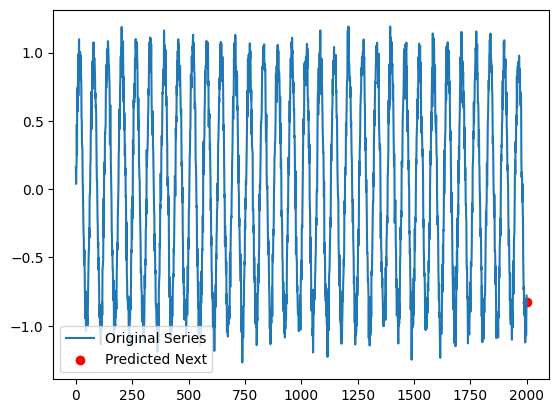

In [ ]:
plt.plot(series, label='Original Series')
plt.scatter(len(series), next_value[0][0], color='red', label='Predicted Next')
plt.legend()
plt.show()